# **Binary Model**

## Libraries

In [1]:
# Libraries
import sys
import os
import re
import random
import shutil
import math

import pandas as pd
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import load_img, img_to_array, smart_resize, ImageDataGenerator

from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dense, Activation, GlobalAveragePooling2D, Input, BatchNormalization, Dropout, Lambda, GlobalMaxPooling2D, Concatenate
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
from focal_loss import BinaryFocalLoss

import optuna

from deep.constants import DATA_DIR, IMAGE_DIR
from deep.preprocessing.label_oversampler import compute_effective_class_weights

2025-04-19 23:01:40.057387: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-19 23:01:40.069397: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-19 23:01:40.089711: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-19 23:01:40.093714: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-19 23:01:40.104209: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [3]:
# Load the metadata
data = pd.read_csv(f'{DATA_DIR}/metadata.csv')

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

In [4]:
# # Creating a sample
# train_df, sample_df = train_test_split(
#     data,
#     test_size=0.3,
#     stratify=data['family'],
#     random_state=20
# )

## Data Preprocessing

In [5]:
# Performing the splits
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['is_animal'], random_state=20)  # Create test set
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['is_animal'], random_state=20)  # Create validation set

In [6]:
# Load the metadata file with the new cropped images
cropped_df = pd.read_csv(f'{DATA_DIR}/cropped_images.csv')

In [7]:
# Add the new metadata to train_df
train_df = pd.concat([
    train_df
    ,cropped_df
], ignore_index=True
, axis=0
)

In [8]:
# Changing target to string
train_df['is_animal'] = train_df['is_animal'].astype(str)
val_df['is_animal'] = val_df['is_animal'].astype(str)
test_df['is_animal'] = test_df['is_animal'].astype(str)

In [9]:
# # Encoding the target
# enc = LabelEncoder()

# train_df['family'] = enc.fit_transform(train_df['family'])
# val_df['family'] = enc.transform(val_df['family'])
# test_df['family'] = enc.transform(test_df['family'])

In [10]:
# Image resizing target dimensions
IMG_SIZE = 224
BATCH_SIZE = 8

In [11]:
def smart_resize_img(image, target_size=(IMG_SIZE, IMG_SIZE)):
    resized_img = smart_resize(image, target_size)  # Resize image
    resized_img /= 255.0  # Normalize the image
    
    return resized_img

In [12]:
# # Resizing the images
# label_train_generator = smart_resize_generator(train_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('train resizing completed')
# label_val_generator = smart_resize_generator(val_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('validation resizing completed')
# label_test_generator = smart_resize_generator(test_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('test resizing completed')

In [13]:
# # Transformation functions
# def rotate_right(img): return img.rotate(-90, expand=True)
# def rotate_left(img): return img.rotate(90, expand=True)
# def flip_horizontal(img): return ImageOps.mirror(img)
# def shear(img):
#     shear_transform = transforms.RandomAffine(degrees=0, shear=20)
#     return shear_transform(img)
# def zoom(img):
#     zoom_transform = transforms.RandomAffine(degrees=0, scale=(0.8, 1.5))
#     return zoom_transform(img)


# transformations = {
#     "rotate_right": rotate_right,
#     "rotate_left": rotate_left,
#     "flip": flip_horizontal,
#     # "shear": shear,
#     # "zoom": zoom
# }

# def augment_images(df, output_dir, target_per_class):
#     os.makedirs(output_dir, exist_ok=True)
#     class_counts = df['label'].value_counts()
#     max_count = class_counts.max()

#     # Identify minority classes
#     minority_classes = class_counts[class_counts < max_count].index

#     # List to hold new rows for augmented images
#     augmented_rows = []

#     for label in minority_classes:
#         class_df = df[df['label'] == label]
#         num_to_generate = target_per_class

#         if num_to_generate <= 0:
#             continue

#         label_dir = os.path.join(output_dir, str(label))
#         os.makedirs(label_dir, exist_ok=True)

#         for _ in range(num_to_generate):
#             row = class_df.sample(1).iloc[0]
#             img_path = row['file_path']
#             original_name = img_path[:-4]
#             ext = img_path[-4:]

#             try:
#                 img = Image.open(f'{IMAGE_DIR}/{img_path}')  # .convert('RGB')
#             except Exception as e:
#                 print(f"Error loading {img_path}: {e}")
#                 continue

#             # Apply random transformation
#             transform_name, transform_fn = random.choice(list(transformations.items()))
#             new_img = transform_fn(img)
#             new_filename = f"{original_name}_{transform_name}{ext}"
#             new_img_path = new_filename
#             new_img.save(f'{IMAGE_DIR}/{new_filename}')

#             # Create a new row for the augmented image and append it to augmented_rows
#             new_row = row.copy()
#             new_row['file_path'] = new_img_path  # Update the file path to the new image
#             augmented_rows.append(new_row)

#     # Add augmented rows to the original dataframe
#     augmented_df = pd.DataFrame(augmented_rows)
#     updated_df = pd.concat([df, augmented_df], ignore_index=True)

#     return updated_df

In [14]:
# # Clean created images
# for filename in os.listdir(IMAGE_DIR):
#     # Check if there's any letter in the filename
#     if re.search(r'[a-zA-Z]', filename[:-4]):
#         file_path = os.path.join(IMAGE_DIR, filename)
#         if os.path.isfile(file_path):
#             os.remove(file_path)
#             print(f"Deleted: {file_path}")

In [15]:
## Create augmented images
# updated_df = augment_images(train_df, output_dir=IMAGE_DIR, target_per_class=6500)

In [16]:
def show_augmented_images(generator, num_images=8):
    images, labels = next(generator)

    actual_num = min(num_images, len(images))  # Avoid index errors

    max_cols = 4
    rows = math.ceil(actual_num / max_cols)
    plt.figure(figsize=(max_cols * 3, rows * 3))

    for i in range(actual_num):
        plt.subplot(rows, max_cols, i + 1)
        plt.imshow(images[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [17]:
# # Undersampling the animal images
# class_0_df = train_df[train_df['label'] == 0]
# class_1_df = train_df[train_df['label'] == 1]

# # Downsample class 1 to 1500
# class_1_downsampled = class_1_df.sample(n=1500, random_state=20)

# # Combine them back
# balanced_train_df = pd.concat(
#     [class_0_df, class_1_downsampled]
# ).sample(
#     frac=1.0
#     ,random_state=20
# ).reset_index(drop=True)

In [18]:
train_datagen = ImageDataGenerator(
    rotation_range=90,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    channel_shift_range=30.0,
    zoom_range=(0.8, 1.2),
    preprocessing_function=smart_resize_img
)
test_datagen = ImageDataGenerator(preprocessing_function=smart_resize_img)

# Train generator
binary_train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='is_animal',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True  # shuffle for training
)

# Validation generator
binary_val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='is_animal',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Test generator
binary_test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='is_animal',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 9533 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


I0000 00:00:1745100103.078614   39060 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745100103.118549   39060 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745100103.118777   39060 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745100103.119794   39060 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

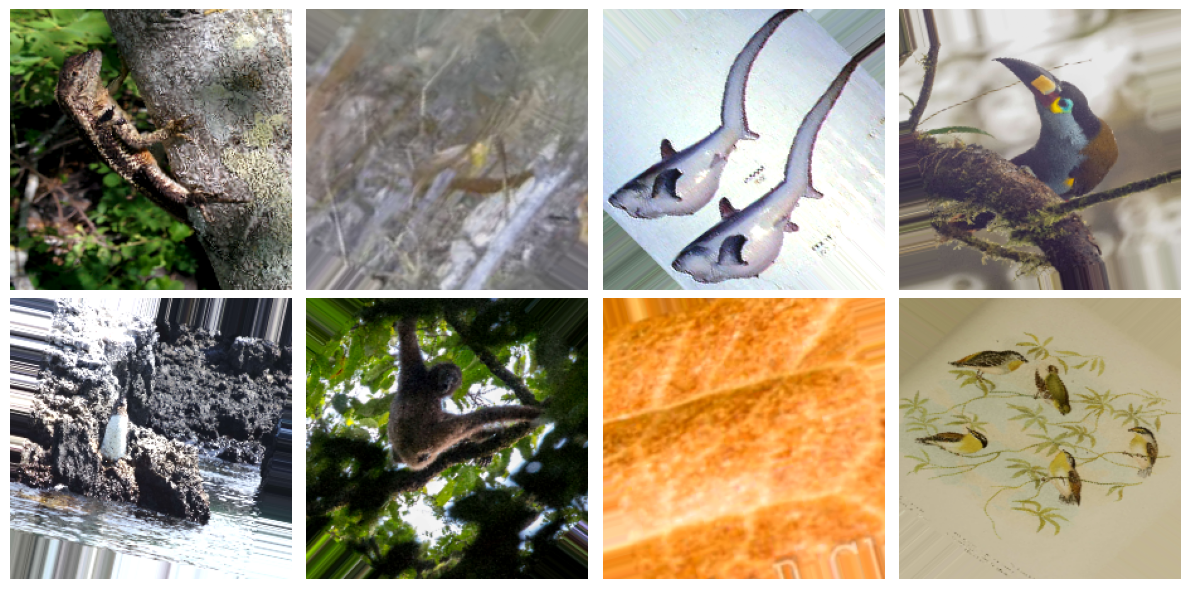

In [19]:
# Show augmented images - rerun for new batch
show_augmented_images(binary_train_generator, num_images=BATCH_SIZE)

## Modelling

In [20]:
# Compute class weights
class_weights = compute_effective_class_weights(train_df, 'is_animal')
# best_accuracy = 0

In [21]:
# # Optuna
# def objective(trial):
#     """
#     Objective function for Optuna hyperparameter optimization.
    
#     Args:
#     - trial (optuna.trial.Trial): The trial object used to sample hyperparameters.
    
#     Returns:
#     - float: The evaluation metric (validation accuracy or other).
#     """
#     global best_accuracy

#     # Define optuna parameters
#     lr = trial.suggest_float("lr", 1e-6, 1e-1)
#     optimizer_type = trial.suggest_categorical("optimizer", ["adam", "sgd"])
#     gamma = trial.suggest_int("gamma", 1, 5)
#     patience = trial.suggest_int("patience", 1, 3)
#     lr_factor = trial.suggest_float("lr_factor", 0.1, 0.7)
#     lr_patience = trial.suggest_int("lr_patience", 1, 5)

#     # Set the input
#     input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
#     # Apply preprocessing to the input tensor
#     x = Lambda(preprocess_input)(input_tensor)

#     # Load the pre-trained model
#     base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
#     # Freeze layers
#     base_model.trainable = False

#     # Add top layers
#     gap = GlobalAveragePooling2D()(x)
#     gmp = GlobalMaxPooling2D()(x)
#     x = Concatenate()([gap, gmp])
#     x = Dense(128, activation='relu')(x)
#     x = BatchNormalization()(x)
#     x = Dropout(0.5)(x)
#     output = Dense(1, activation='sigmoid')(x)  # Binary classification

#     binary_model = Model(inputs=input_tensor, outputs=output)

#     # Optimizer setup based on dynamic 'optimizer_type'
#     if optimizer_type == "adam":
#         optimizer = Adam(learning_rate=lr)
#     elif optimizer_type == "sgd":
#         optimizer = SGD(learning_rate=lr)
#     else:
#         raise ValueError(f"Unknown optimizer type: {optimizer_type}")
    
#     # Compiling the model
#     binary_model.compile(
#         optimizer=optimizer
#         ,loss=BinaryFocalLoss(
#             gamma=gamma
#             ,pos_weight=class_weights[1] / (class_weights[0] + class_weights[1])
#         )
#         ,metrics=['accuracy', AUC(), 'precision', 'recall']
#     )

#     # Fit the model
#     fitted_binary = binary_model.fit(
#         binary_train_generator
#         ,validation_data=binary_val_generator
#         ,epochs=5
#         ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
#         ,class_weight=class_weights
#         ,callbacks=[
#             EarlyStopping(patience=patience, restore_best_weights=True)
#             ,ReduceLROnPlateau(patience=lr_patience, factor=lr_factor, verbose=1)
#         ]
#         ,verbose=1
#     )

#     # Evaluate the model using the validation set
#     _, val_accuracy, _, _, _ = binary_model.evaluate(binary_val_generator, verbose=0)

#     # Save the model if it's the best so far
#     if val_accuracy > best_accuracy:
#         best_auc = val_accuracy
#         binary_model.save("best_binary_model.keras")
#         print(f"Saved new best model (Accuracy: {val_accuracy:.4f})")
    
#     # Return the validation accuracy as the objective metric
#     return val_accuracy

In [22]:
# # Create a study
# study = optuna.create_study(direction="maximize")

# # Optimize the objective function
# study.optimize(lambda trial: objective(trial), n_trials=3)

# # Get the best trial's hyperparameters
# print(f"Best trial: {study.best_trial.params}")

In [23]:
# # Build the model

# # Set the input
# input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# # Apply preprocessing to the input tensor
# x = Lambda(preprocess_input)(input_tensor)

# # Load the pre-trained model
# base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
# # Freeze layers
# base_model.trainable = False

# # Add top layers
# gap = GlobalAveragePooling2D()(base_model.output)
# gmp = GlobalMaxPooling2D()(base_model.output)
# x = Concatenate()([gap, gmp])
# x = Dense(128, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.5)(x)
# output = Dense(1, activation='sigmoid')(x)  # Binary classification

# binary_model = Model(inputs=input_tensor, outputs=output)

In [24]:
# Define the CNN model
binary_model = Sequential()

# Input Layer + 1st Convolutional Block
binary_model.add(Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
binary_model.add(Activation('relu'))
binary_model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Convolutional Block
binary_model.add(Conv2D(64, (3, 3), padding='same'))
binary_model.add(Activation('relu'))
binary_model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Convolutional Block
binary_model.add(Conv2D(128, (3, 3), padding='same'))
binary_model.add(Activation('relu'))
binary_model.add(MaxPooling2D(pool_size=(2, 2)))

# 4th Convolutional Block
binary_model.add(Conv2D(259, (3, 3), padding='same'))
binary_model.add(Activation('relu'))
binary_model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully Connected Layer
binary_model.add(Flatten())
binary_model.add(Dense(128))
binary_model.add(Activation('relu'))

# Output Layer for Binary Classification
binary_model.add(Dense(1, activation='sigmoid'))

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# Compiling the model
binary_model.compile(
    optimizer=Adam(learning_rate=0.01)
    ,loss=BinaryFocalLoss(
        gamma=5
        ,pos_weight=class_weights['1'] / (class_weights['0'] + class_weights['1'])
    )
    # ,loss='binary_crossentropy'
    ,metrics=['accuracy', AUC(), 'precision', 'recall']
)

In [26]:
# # Show model summary
# binary_model.summary()

In [27]:
# Fit the model
fitted_binary = binary_model.fit(
    binary_train_generator
    ,validation_data=binary_val_generator
    ,epochs=5
    ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
    ,class_weight=class_weights
    ,callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True)
        ,ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ]
    ,verbose=1
)

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1745100108.113931   39118 service.cc:146] XLA service 0x7a0370010710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745100108.113958   39118 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-19 23:01:48.169490: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-19 23:01:48.395229: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100


   2/1192 ━━━━━━━━━━━━━━━━━━━━ 1:16 64ms/step - accuracy: 0.3750 - auc: 0.6172 - loss: 1.0165 - precision: 0.8889 - recall: 0.3407 

2025-04-19 23:01:54.360657: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_3', 4 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_3', 36 bytes spill stores, 36 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_6', 4 bytes spill stores, 12 bytes spill loads

I0000 00:00:1745100114.369363   39118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 444/1192 ━━━━━━━━━━━━━━━━━━━━ 4:35 369ms/step - accuracy: 0.7959 - auc: 0.4980 - loss: 3.1074 - precision: 0.8049 - recall: 0.9861

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


1084/1192 ━━━━━━━━━━━━━━━━━━━━ 40s 376ms/step - accuracy: 0.7979 - auc: 0.4990 - loss: 3.1731 - precision: 0.8021 - recall: 0.9935

2025-04-19 23:08:41.812466: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_7', 4 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_3', 4 bytes spill stores, 12 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_3', 36 bytes spill stores, 36 bytes spill loads



1192/1192 ━━━━━━━━━━━━━━━━━━━━ 522s 431ms/step - accuracy: 0.7976 - auc: 0.4991 - loss: 3.1844 - precision: 0.8014 - recall: 0.9941 - val_accuracy: 0.9291 - val_auc: 0.5000 - val_loss: 1.1425 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0100
Epoch 2/5
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 510s 428ms/step - accuracy: 0.7896 - auc: 0.4996 - loss: 3.3911 - precision: 0.7896 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc: 0.5000 - val_loss: 1.1425 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0100
Epoch 3/5
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.7996 - auc: 0.5000 - loss: 3.2306 - precision: 0.7996 - recall: 1.0000
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 511s 429ms/step - accuracy: 0.7996 - auc: 0.5000 - loss: 3.2306 - precision: 0.7996 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc: 0.5000 - val_loss: 1.1425 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate:

In [28]:
# Get the average from model metrics
history = fitted_binary.history
average_metrics = {metric: np.mean(values) for metric, values in history.items()}

for metric, avg in average_metrics.items():
    print(f"{metric}: {avg:.4f}")

accuracy: 0.7943
auc: 0.4999
loss: 3.3135
precision: 0.7944
recall: 0.9998
val_accuracy: 0.9291
val_auc: 0.5000
val_loss: 1.1425
val_precision: 0.9291
val_recall: 1.0000
learning_rate: 0.0087


In [29]:
# # Export the model
# binary_model.save('../models/binary_model.keras')

In [30]:
# # Load the model
# binary_model = load_model('best_binary_model')

In [31]:
# Make predictions
predictions = binary_model.predict(
    binary_test_generator
    ,steps=len(binary_test_generator)
    ,verbose=1
)

300/300 ━━━━━━━━━━━━━━━━━━━━ 98s 326ms/step


In [32]:
# Get the true labels
y_true = binary_test_generator.labels

# Convert predictions to class labels
y_pred = (predictions > 0.5).astype(int).flatten()

# Calculate metrics
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")

Accuracy: 0.9295
Precision: 0.9295
Recall: 1.0000


In [33]:
# Get unique values and their counts
unique, counts = np.unique(y_pred, return_counts=True)

# Display the result
value_counts = dict(zip(unique, counts))
print(value_counts)

{1: 2397}


In [34]:
# # Save the predictions
# file_paths = binary_test_generator.filenames
# pred_df = pd.DataFrame({
#     'file_path': file_paths,
#     'predictions': (predictions > 0.5).astype(int).flatten()
# })

# # Export to csv
# # pred_df.to_csv('../models/binary_predictions.csv', index=False)